# ClearBank — Análise Financeira com Python

## Instruções

Este notebook lê o arquivo `transacoes.csv`, valida cada linha, gera métricas financeiras mensais, sinaliza transações suspeitas, exibe um relatório formatado e salva o resultado em `relatorio.json`.

**Antes de executar:** o arquivo `transacoes.csv` precisa estar na mesma pasta do notebook (no Google Colab, envie-o pelo painel **Arquivos** à esquerda). Colunas esperadas:

```
id,data,cliente_id,tipo,valor,descricao,categoria
```

O arquivo de teste contém 18 registros válidos (janeiro a abril de 2026), 14 inválidos (pelo menos um para cada regra de validação) e 3 transações acima de R$ 10.000,00.

**Como executar:** rode todas as células em ordem (no Colab: *Ambiente de execução → Executar tudo*). Cada célula de função termina com um teste rápido; a **Célula de Execução Principal**, no final, chama todas as funções juntas.

**Ordem das células:** configuração → leitura → validação → limpeza → datas → métricas → JSON → relatório → execução principal.

In [1]:
# ===== Configuração: módulos nativos e constantes =====
import csv
import json
import math
from datetime import datetime

# Valor acima do qual (estritamente maior) a transação é marcada como suspeita
LIMITE_SUSPEITO = 10000.00

ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
ARQUIVO_GRAFICO = "grafico.png"

# Teste rápido: confirma as constantes usadas no restante do notebook
print(f"LIMITE_SUSPEITO = {LIMITE_SUSPEITO}")
print(f"Entrada: {ARQUIVO_CSV} | Saídas: {ARQUIVO_JSON}, {ARQUIVO_GRAFICO}")

LIMITE_SUSPEITO = 10000.0
Entrada: transacoes.csv | Saídas: relatorio.json, grafico.png


## 1. Leitura do arquivo CSV

`ler_transacoes()` usa `csv.DictReader` (acesso às colunas pelo nome) e trata `FileNotFoundError`: se o arquivo não existir, avisa e devolve uma lista vazia, sem quebrar o notebook. Os valores ainda são textos brutos; a validação vem na próxima seção.

In [2]:
# ===== Leitura do CSV =====
def ler_transacoes(caminho=ARQUIVO_CSV):
    """Lê o CSV e retorna a lista de transações brutas (cada linha é um dict de textos)."""
    try:
        # encoding explícito: no Windows o padrão não é UTF-8 e os acentos quebrariam;
        # newline="" é o recomendado pela documentação do módulo csv
        with open(caminho, encoding="utf-8", newline="") as arquivo:
            return list(csv.DictReader(arquivo))
    except FileNotFoundError:
        # Não interrompe o notebook: avisa e devolve lista vazia
        print(f"Aviso: arquivo '{caminho}' não encontrado. Coloque-o na pasta do notebook.")
        return []


# Teste rápido
transacoes_brutas = ler_transacoes()
print(f"Linhas lidas (sem o cabeçalho): {len(transacoes_brutas)}")
print("Colunas:", list(transacoes_brutas[0].keys()) if transacoes_brutas else "nenhuma")
print("Primeira linha bruta:", transacoes_brutas[:1])
print("Teste de FileNotFoundError (arquivo inexistente) devolve:", ler_transacoes("arquivo_inexistente.csv"))

Linhas lidas (sem o cabeçalho): 32
Colunas: ['id', 'data', 'cliente_id', 'tipo', 'valor', 'descricao', 'categoria']
Primeira linha bruta: [{'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salário janeiro', 'categoria': 'salario'}]
Aviso: arquivo 'arquivo_inexistente.csv' não encontrado. Coloque-o na pasta do notebook.
Teste de FileNotFoundError (arquivo inexistente) devolve: []


## 2. Validação de cada linha

Uma linha é descartada se tiver: `id` vazio ou não numérico, `cliente_id` vazio, `data` fora do formato `AAAA-MM-DD`, `tipo` diferente de `credito`/`debito`, ou `valor` não numérico ou menor ou igual a zero.

Funções auxiliares, uma por campo, cada uma com seu `try/except ValueError`:

- `validar_data()`: exige 10 caracteres **e** `strptime("%Y-%m-%d")`. Só o `strptime` aceitaria `2026-1-5`, que não está no formato `AAAA-MM-DD`.
- `validar_valor()`: `float()` aceita `"nan"` e `"inf"`; por isso também é exigido `math.isfinite()` e valor `> 0`.
- `validar_id()`: `int()` rejeita id vazio ou não numérico.

`validar_transacao()` junta as regras e devolve o registro limpo (tipos convertidos) ou `None` quando a linha é inválida.

In [3]:
# ===== Validação =====
def validar_id(texto):
    """Converte o id para inteiro; devolve None se estiver vazio ou não for numérico."""
    try:
        return int(texto)
    except ValueError:
        return None


def validar_data(texto):
    """Converte 'AAAA-MM-DD' em datetime; devolve None se o formato for inválido."""
    # strptime aceita "2026-1-5"; exigir 10 caracteres garante o formato AAAA-MM-DD
    if len(texto) != 10:
        return None
    try:
        return datetime.strptime(texto, "%Y-%m-%d")
    except ValueError:  # ex.: "2026/03/10" ou "2026-02-30"
        return None


def validar_valor(texto):
    """Converte o valor para float; devolve None se não for numérico ou se for <= 0."""
    try:
        valor = float(texto)
    except ValueError:
        return None
    # float() aceita "nan" e "inf", que não são valores monetários válidos
    if not math.isfinite(valor) or valor <= 0:
        return None
    return valor


def validar_transacao(linha):
    """Valida uma única linha bruta e retorna o registro limpo, ou None se for inválida."""
    # "or ''" cobre colunas ausentes: o DictReader preenche com None
    campo = {chave: (linha.get(chave) or "").strip() for chave in linha if chave}
    id_transacao = validar_id(campo.get("id", ""))
    data = validar_data(campo.get("data", ""))
    valor = validar_valor(campo.get("valor", ""))
    cliente_id = campo.get("cliente_id", "")
    tipo = campo.get("tipo", "")
    if None in (id_transacao, data, valor) or not cliente_id or tipo not in ("credito", "debito"):
        return None
    return {"id": id_transacao, "data": data, "cliente_id": cliente_id, "tipo": tipo,
            "valor": valor, "descricao": campo.get("descricao", ""),
            "categoria": campo.get("categoria", "")}


# Teste rápido: uma linha válida de base, alterada em um campo por caso
base = {"id": "1", "data": "2026-01-05", "cliente_id": "CLI001", "tipo": "credito",
        "valor": "3500.00", "descricao": "Salário janeiro", "categoria": "salario"}
casos = [
    ("linha válida", {}, True),
    ("id vazio", {"id": ""}, False),
    ("id não numérico", {"id": "abc"}, False),
    ("cliente_id vazio", {"cliente_id": "   "}, False),
    ("data com barras", {"data": "2026/01/05"}, False),
    ("data sem zeros", {"data": "2026-1-5"}, False),
    ("data inexistente", {"data": "2026-02-30"}, False),
    ("tipo inválido", {"tipo": "transferencia"}, False),
    ("valor não numérico", {"valor": "abc"}, False),
    ("valor com vírgula", {"valor": "1500,00"}, False),
    ("valor zero", {"valor": "0"}, False),
    ("valor negativo", {"valor": "-50.00"}, False),
    ("valor nan", {"valor": "nan"}, False),
    ("valor inf", {"valor": "inf"}, False),
    ("coluna ausente (None)", {"valor": None}, False),
]
for nome, alteracao, esperado in casos:
    valida = validar_transacao({**base, **alteracao}) is not None
    status = "OK" if valida == esperado else "FALHOU"
    print(f"{status:6} | {nome:22} | válida? {valida}")

limpas = [t for t in map(validar_transacao, transacoes_brutas) if t is not None]
print(f"\nNo transacoes.csv: {len(limpas)} válidas de {len(transacoes_brutas)} linhas")
print("Registro limpo:", limpas[0] if limpas else "nenhum")

OK     | linha válida           | válida? True
OK     | id vazio               | válida? False
OK     | id não numérico        | válida? False
OK     | cliente_id vazio       | válida? False
OK     | data com barras        | válida? False
OK     | data sem zeros         | válida? False
OK     | data inexistente       | válida? False
OK     | tipo inválido          | válida? False
OK     | valor não numérico     | válida? False
OK     | valor com vírgula      | válida? False
OK     | valor zero             | válida? False
OK     | valor negativo         | válida? False
OK     | valor nan              | válida? False
OK     | valor inf              | válida? False
OK     | coluna ausente (None)  | válida? False

No transacoes.csv: 18 válidas de 32 linhas
Registro limpo: {'id': 1, 'data': datetime.datetime(2026, 1, 5, 0, 0), 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': 3500.0, 'descricao': 'Salário janeiro', 'categoria': 'salario'}


## 3. Limpeza e transações suspeitas

`limpar_transacoes()` percorre as linhas brutas, valida cada uma e descarta silenciosamente as inválidas (o processamento continua). No mesmo laço, as transações com valor **acima** de `LIMITE_SUSPEITO` vão para uma lista separada de suspeitas. `exibir_resumo_limpeza()` imprime o resumo pedido no enunciado.

In [4]:
# ===== Limpeza e suspeitas =====
def limpar_transacoes(transacoes_brutas):
    """Valida as linhas brutas; devolve (válidas, quantidade de inválidas, suspeitas)."""
    validas, suspeitas = [], []
    for linha in transacoes_brutas:
        transacao = validar_transacao(linha)
        if transacao is None:
            continue  # linha inválida: descartada sem interromper o processamento
        validas.append(transacao)
        if transacao["valor"] > LIMITE_SUSPEITO:  # estritamente acima do limite
            suspeitas.append(transacao)
    invalidas = len(transacoes_brutas) - len(validas)
    return validas, invalidas, suspeitas


def exibir_resumo_limpeza(total_lidas, total_validas, total_invalidas):
    """Imprime o resumo da limpeza no formato do enunciado."""
    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas válidas: {total_validas}")
    print(f"Linhas inválidas: {total_invalidas}")


# Teste 1: as 8 primeiras linhas do CSV são o exemplo do enunciado (esperado: 8 / 6 / 2)
validas, invalidas, suspeitas = limpar_transacoes(transacoes_brutas[:8])
print("Exemplo do enunciado:")
exibir_resumo_limpeza(len(transacoes_brutas[:8]), len(validas), invalidas)

# Teste 2: arquivo completo (esperado: 32 / 18 / 14; suspeitas 5, 12 e 17)
validas, invalidas, suspeitas = limpar_transacoes(transacoes_brutas)
print("\nArquivo completo:")
exibir_resumo_limpeza(len(transacoes_brutas), len(validas), invalidas)
print("IDs suspeitos:", [t["id"] for t in suspeitas])
print("ID 11 (exatamente R$ 10.000,00) é suspeito?", any(t["id"] == 11 for t in suspeitas))

Exemplo do enunciado:
Total de linhas lidas: 8
Linhas válidas: 6
Linhas inválidas: 2

Arquivo completo:
Total de linhas lidas: 32
Linhas válidas: 18
Linhas inválidas: 14
IDs suspeitos: [5, 12, 17]
ID 11 (exatamente R$ 10.000,00) é suspeito? False


## 4. Datas

As datas já foram convertidas para `datetime` com `strptime` na validação. Aqui:

- `extrair_mes()` usa `strftime("%Y-%m")` para obter o mês no formato `AAAA-MM`, que é a chave do agrupamento mensal.
- `calcular_periodo()` encontra a transação mais antiga, a mais recente e quantos dias se passaram entre elas.

In [5]:
# ===== Datas =====
def extrair_mes(data):
    """Devolve o mês da transação no formato AAAA-MM."""
    return data.strftime("%Y-%m")


def calcular_periodo(transacoes):
    """Devolve (data mais antiga, data mais recente, dias entre elas), ou None se não houver dados."""
    if not transacoes:  # min()/max() de lista vazia gerariam erro
        return None
    datas = [t["data"] for t in transacoes]
    inicio, fim = min(datas), max(datas)
    return inicio, fim, (fim - inicio).days  # subtrair datetimes gera um timedelta


# Teste rápido (esperado: 2026-01-05 → 2026-04-30, 115 dias)
periodo = calcular_periodo(validas)
if periodo is None:
    print("Período analisado: nenhuma transação válida")
else:
    inicio, fim, dias = periodo
    print(f"Período analisado: {inicio:%Y-%m-%d} → {fim:%Y-%m-%d} ({dias} dias)")
print("Meses encontrados:", sorted({extrair_mes(t["data"]) for t in validas}))
print("Lista vazia devolve:", calcular_periodo([]))

Período analisado: 2026-01-05 → 2026-04-30 (115 dias)
Meses encontrados: ['2026-01', '2026-02', '2026-03', '2026-04']
Lista vazia devolve: None


## 5. Agrupamento mensal e métricas

As métricas ficam num dicionário com o mês (`AAAA-MM`) como chave:

- `acumular_transacao()` soma cada transação no mês dela (quantidade, crédito, débito, maior e menor valor).
- `finalizar_mes()` calcula saldo (crédito − débito) e média por transação, e arredonda tudo para 2 casas.
- `gerar_relatorio()` junta tudo na mesma estrutura do `relatorio.json` pedida no enunciado, com os meses em ordem cronológica.

In [6]:
# ===== Métricas mensais =====
def acumular_transacao(resumo, transacao):
    """Soma uma transação válida nos acumuladores do mês dela."""
    mes, valor = extrair_mes(transacao["data"]), transacao["valor"]
    if mes not in resumo:
        resumo[mes] = {"quantidade": 0, "total_credito": 0.0, "total_debito": 0.0,
                       "maior_valor": valor, "menor_valor": valor}
    acumulado = resumo[mes]
    acumulado["quantidade"] += 1
    acumulado["total_" + transacao["tipo"]] += valor  # tipo já validado: credito ou debito
    acumulado["maior_valor"] = max(acumulado["maior_valor"], valor)
    acumulado["menor_valor"] = min(acumulado["menor_valor"], valor)


def finalizar_mes(acumulado):
    """Calcula saldo e média do mês e arredonda tudo para 2 casas, na ordem do JSON."""
    credito, debito = acumulado["total_credito"], acumulado["total_debito"]
    return {
        "quantidade": acumulado["quantidade"],
        "total_credito": round(credito, 2),
        "total_debito": round(debito, 2),
        "saldo": round(credito - debito, 2),
        "media": round((credito + debito) / acumulado["quantidade"], 2),
        "maior_valor": round(acumulado["maior_valor"], 2),
        "menor_valor": round(acumulado["menor_valor"], 2),
    }


def gerar_relatorio(validas, total_invalidas, suspeitas):
    """Agrupa as transações por mês e monta o relatório na estrutura do relatorio.json."""
    resumo = {}
    for transacao in validas:
        acumular_transacao(resumo, transacao)
    return {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas": len(validas),
        "total_transacoes_invalidas": total_invalidas,
        # sorted: o CSV não está em ordem de data, mas o relatório deve sair cronológico
        "resumo_mensal": {mes: finalizar_mes(resumo[mes]) for mes in sorted(resumo)},
        "transacoes_suspeitas": [
            {"id": t["id"], "cliente_id": t["cliente_id"],
             "data": t["data"].strftime("%Y-%m-%d"), "valor": round(t["valor"], 2)}
            for t in suspeitas
        ],
    }


# Teste rápido: janeiro deve ser idêntico ao exemplo do enunciado
relatorio = gerar_relatorio(validas, invalidas, suspeitas)
janeiro_enunciado = {"quantidade": 2, "total_credito": 3500.00, "total_debito": 180.50,
                     "saldo": 3319.50, "media": 1840.25, "maior_valor": 3500.00,
                     "menor_valor": 180.50}
# .get evita KeyError se o CSV não tiver janeiro (ex.: arquivo ausente)
print("Janeiro igual ao enunciado?", relatorio["resumo_mensal"].get("2026-01") == janeiro_enunciado)
print("Gerado em:", relatorio["gerado_em"])
print(f"Válidas: {relatorio['total_transacoes_validas']} | "
      f"Inválidas: {relatorio['total_transacoes_invalidas']}")
for mes, metricas in relatorio["resumo_mensal"].items():
    print(mes, metricas)
print("Suspeitas:", relatorio["transacoes_suspeitas"])

Janeiro igual ao enunciado? True
Gerado em: 2026-10-03
Válidas: 18 | Inválidas: 14
2026-01 {'quantidade': 2, 'total_credito': 3500.0, 'total_debito': 180.5, 'saldo': 3319.5, 'media': 1840.25, 'maior_valor': 3500.0, 'menor_valor': 180.5}
2026-02 {'quantidade': 5, 'total_credito': 18500.0, 'total_debito': 11570.0, 'saldo': 6930.0, 'media': 6014.0, 'maior_valor': 15000.0, 'menor_valor': 320.0}
2026-03 {'quantidade': 5, 'total_credito': 18800.0, 'total_debito': 550.65, 'saldo': 18249.35, 'media': 3870.13, 'maior_valor': 12500.0, 'menor_valor': 99.9}
2026-04 {'quantidade': 6, 'total_credito': 5000.0, 'total_debito': 25742.1, 'saldo': -20742.1, 'media': 5123.68, 'maior_valor': 25000.0, 'menor_valor': 39.9}
Suspeitas: [{'id': 5, 'cliente_id': 'CLI003', 'data': '2026-02-14', 'valor': 15000.0}, {'id': 12, 'cliente_id': 'CLI004', 'data': '2026-03-15', 'valor': 12500.0}, {'id': 17, 'cliente_id': 'CLI002', 'data': '2026-04-11', 'valor': 25000.0}]


## 6. Exportação em JSON

`salvar_json()` grava o relatório em `relatorio.json` com `ensure_ascii=False` (mantém os acentos legíveis) e `indent=2` (formatado). Se a gravação falhar (por exemplo, por falta de permissão), avisa sem interromper o notebook.

In [7]:
# ===== Exportação JSON =====
def salvar_json(relatorio, caminho=ARQUIVO_JSON):
    """Salva o relatório em JSON; devolve True se conseguiu gravar."""
    try:
        with open(caminho, "w", encoding="utf-8") as arquivo:
            json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)
    except OSError as erro:  # ex.: pasta sem permissão de escrita
        print(f"Aviso: não foi possível salvar '{caminho}': {erro}")
        return False
    print(f"Relatório salvo em '{caminho}'.")
    return True


# Teste rápido: salva, relê o arquivo e compara com o relatório em memória
salvar_json(relatorio)
with open(ARQUIVO_JSON, encoding="utf-8") as arquivo:
    relido = json.load(arquivo)
print("Conteúdo relido igual ao relatório gerado?", relido == relatorio)
print("Chaves do JSON:", list(relido.keys()))

Relatório salvo em 'relatorio.json'.
Conteúdo relido igual ao relatório gerado? True
Chaves do JSON: ['gerado_em', 'total_transacoes_validas', 'total_transacoes_invalidas', 'resumo_mensal', 'transacoes_suspeitas']


## 7. Relatório no terminal

- `formatar_moeda()` aplica o padrão brasileiro (`R$ 3.500,00`) com a f-string sugerida no enunciado.
- `formatar_mes()` e `formatar_suspeita()` montam as linhas no mesmo formato dos exemplos do enunciado (por devolverem texto, dá para testá-las comparando com o exemplo).
- `exibir_suspeitas()` lista as transações suspeitas ou informa que não há nenhuma.
- `exibir_relatorio()` imprime tudo com separadores `=====`: período analisado, totais de válidas e inválidas, relatório mensal e suspeitas.

In [8]:
# ===== Relatório no terminal =====
def formatar_moeda(valor):
    """Formata um número no padrão brasileiro: 3500.0 -> 'R$ 3.500,00'."""
    # troca temporária por "X" para inverter os separadores americanos (, e .)
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def formatar_mes(mes, metricas):
    """Monta as linhas de um mês no formato do enunciado."""
    return [
        f"Mês: {mes}",
        f"  Transações: {metricas['quantidade']}",
        f"  Total crédito: {formatar_moeda(metricas['total_credito'])}",
        f"  Total débito:  {formatar_moeda(metricas['total_debito'])}",
        f"  Saldo:         {formatar_moeda(metricas['saldo'])}",
        f"  Média:         {formatar_moeda(metricas['media'])}",
        f"  Maior valor:   {formatar_moeda(metricas['maior_valor'])}",
        f"  Menor valor:   {formatar_moeda(metricas['menor_valor'])}",
    ]


def formatar_suspeita(transacao):
    """Monta a linha de uma transação suspeita no formato do enunciado."""
    return (f"ID: {transacao['id']} | Cliente: {transacao['cliente_id']} | "
            f"Data: {transacao['data']} | Valor: {formatar_moeda(transacao['valor'])}")


def exibir_suspeitas(suspeitas):
    """Imprime a seção de transações suspeitas."""
    print("===== TRANSAÇÕES SUSPEITAS =====")
    if not suspeitas:
        print("Nenhuma transação suspeita encontrada.")
    for transacao in suspeitas:
        print(formatar_suspeita(transacao))


def exibir_relatorio(relatorio, periodo):
    """Imprime o relatório completo: período, totais, resumo mensal e suspeitas."""
    print("===== RESUMO DA ANÁLISE =====")
    if periodo is None:
        print("Período analisado: nenhuma transação válida")
    else:
        inicio, fim, dias = periodo
        print(f"Período analisado: {inicio:%Y-%m-%d} → {fim:%Y-%m-%d} ({dias} dias)")
    print(f"Transações válidas: {relatorio['total_transacoes_validas']}")
    print(f"Transações inválidas: {relatorio['total_transacoes_invalidas']}")
    print("\n===== RELATÓRIO MENSAL =====")
    for mes, metricas in relatorio["resumo_mensal"].items():
        print()
        print("\n".join(formatar_mes(mes, metricas)))
    print()
    exibir_suspeitas(relatorio["transacoes_suspeitas"])


# Teste rápido 1: moeda no padrão brasileiro
for numero in (3500, 180.5, 15000, 0.5, 1234567.891, -20742.1):
    print(f"{numero!r:>12} -> {formatar_moeda(numero)}")

# Teste rápido 2: janeiro e a suspeita do exemplo, comparados com o texto do enunciado
janeiro_texto_enunciado = [
    "Mês: 2026-01",
    "  Transações: 2",
    "  Total crédito: R$ 3.500,00",
    "  Total débito:  R$ 180,50",
    "  Saldo:         R$ 3.319,50",
    "  Média:         R$ 1.840,25",
    "  Maior valor:   R$ 3.500,00",
    "  Menor valor:   R$ 180,50",
]
suspeita_texto_enunciado = "ID: 5 | Cliente: CLI003 | Data: 2026-02-14 | Valor: R$ 15.000,00"
# as verificações "in"/"if" evitam erro se o CSV não tiver esses dados (ex.: arquivo ausente)
janeiro = relatorio["resumo_mensal"].get("2026-01")
linhas_suspeitas = [formatar_suspeita(t) for t in relatorio["transacoes_suspeitas"]]
print("\nJaneiro igual ao enunciado?",
      janeiro is not None and formatar_mes("2026-01", janeiro) == janeiro_texto_enunciado)
print("Suspeita igual ao enunciado?", suspeita_texto_enunciado in linhas_suspeitas)

# Teste rápido 3: seção de suspeitas sem nenhuma suspeita
print()
exibir_suspeitas([])

        3500 -> R$ 3.500,00
       180.5 -> R$ 180,50
       15000 -> R$ 15.000,00
         0.5 -> R$ 0,50
 1234567.891 -> R$ 1.234.567,89
    -20742.1 -> R$ -20.742,10

Janeiro igual ao enunciado? True
Suspeita igual ao enunciado? True

===== TRANSAÇÕES SUSPEITAS =====
Nenhuma transação suspeita encontrada.


## 8. Célula de Execução Principal

Chama todas as funções juntas, na ordem: leitura → validação/limpeza → datas → métricas → JSON → relatório. Ao final, `relatorio.json` está salvo e o relatório completo aparece abaixo.

In [9]:
# ===== CÉLULA DE EXECUÇÃO PRINCIPAL =====
def executar_analise():
    """Executa a análise completa: lê, valida, calcula, salva o JSON e exibe o relatório."""
    transacoes_brutas = ler_transacoes()
    validas, invalidas, suspeitas = limpar_transacoes(transacoes_brutas)
    exibir_resumo_limpeza(len(transacoes_brutas), len(validas), invalidas)
    periodo = calcular_periodo(validas)
    relatorio = gerar_relatorio(validas, invalidas, suspeitas)
    salvar_json(relatorio)
    print()
    exibir_relatorio(relatorio, periodo)
    return relatorio


relatorio = executar_analise()  # atribuído para o Jupyter não repetir o dicionário na saída

Total de linhas lidas: 32
Linhas válidas: 18
Linhas inválidas: 14
Relatório salvo em 'relatorio.json'.

===== RESUMO DA ANÁLISE =====
Período analisado: 2026-01-05 → 2026-04-30 (115 dias)
Transações válidas: 18
Transações inválidas: 14

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 2
  Total crédito: R$ 3.500,00
  Total débito:  R$ 180,50
  Saldo:         R$ 3.319,50
  Média:         R$ 1.840,25
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 180,50

Mês: 2026-02
  Transações: 5
  Total crédito: R$ 18.500,00
  Total débito:  R$ 11.570,00
  Saldo:         R$ 6.930,00
  Média:         R$ 6.014,00
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 320,00

Mês: 2026-03
  Transações: 5
  Total crédito: R$ 18.800,00
  Total débito:  R$ 550,65
  Saldo:         R$ 18.249,35
  Média:         R$ 3.870,13
  Maior valor:   R$ 12.500,00
  Menor valor:   R$ 99,90

Mês: 2026-04
  Transações: 6
  Total crédito: R$ 5.000,00
  Total débito:  R$ 25.742,10
  Saldo:         R$ -20.742,10
  Média

## 9. (Opcional — RO2) Gráfico com matplotlib

Opção C do enunciado: barras empilhadas com crédito e débito por mês, salvas em `grafico.png`. Os dados vêm do relatório já calculado pela solução nativa. O `matplotlib` só é importado aqui, para que a solução principal não dependa de bibliotecas externas.

Gráfico salvo em 'grafico.png'.


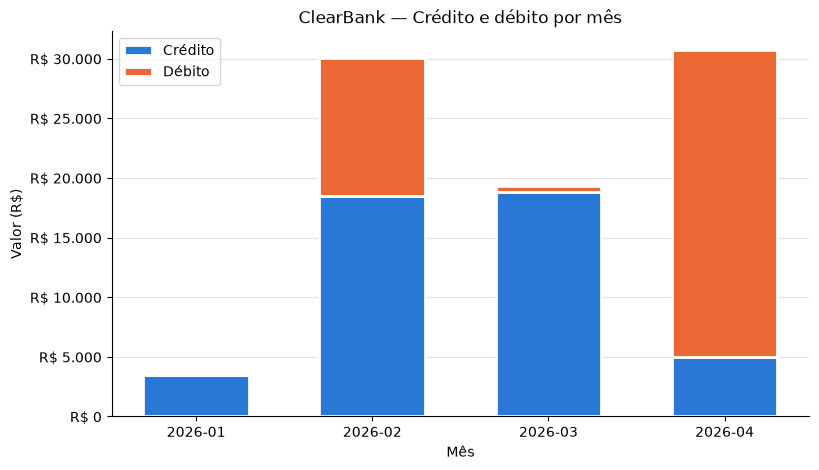

In [10]:
# ===== (Opcional — RO2) Gráfico =====
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:  # rodando local sem matplotlib: pip install matplotlib
    plt = None
    print("Aviso: matplotlib não instalado; gráfico não gerado.")

COR_CREDITO, COR_DEBITO = "#2a78d6", "#eb6834"  # azul/laranja, distinguíveis por daltônicos


def gerar_grafico(relatorio, caminho=ARQUIVO_GRAFICO):
    """Gera barras empilhadas de crédito e débito por mês e salva em PNG."""
    meses = list(relatorio["resumo_mensal"])
    creditos = [m["total_credito"] for m in relatorio["resumo_mensal"].values()]
    debitos = [m["total_debito"] for m in relatorio["resumo_mensal"].values()]
    figura, eixo = plt.subplots(figsize=(9, 5))
    # borda branca de 2px separa visualmente os dois segmentos empilhados
    eixo.bar(meses, creditos, width=0.6, color=COR_CREDITO, edgecolor="white", linewidth=2, label="Crédito")
    eixo.bar(meses, debitos, width=0.6, bottom=creditos, color=COR_DEBITO, edgecolor="white", linewidth=2, label="Débito")
    eixo.set_title("ClearBank — Crédito e débito por mês")
    eixo.set_xlabel("Mês")
    eixo.set_ylabel("Valor (R$)")
    # eixo y no padrão brasileiro, sem centavos: "R$ 10.000"
    eixo.yaxis.set_major_formatter(lambda valor, _: formatar_moeda(valor).rsplit(",", 1)[0])
    eixo.grid(axis="y", color="#e0e0e0")
    eixo.set_axisbelow(True)
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.legend()
    figura.savefig(caminho, dpi=150, bbox_inches="tight")
    return figura


# Teste rápido: gera, salva e exibe o gráfico
if plt is not None and relatorio["resumo_mensal"]:
    gerar_grafico(relatorio)
    print(f"Gráfico salvo em '{ARQUIVO_GRAFICO}'.")
    plt.show()
elif plt is not None:
    print("Sem transações válidas: gráfico não gerado.")

## 10. (Opcional — RO1) Comparação com pandas

A versão com `pandas` fica no arquivo separado `analise_pandas.py`, para não misturar com a solução principal. Ela lê o CSV com `pd.read_csv()`, aplica as mesmas regras de validação, agrupa por mês com `groupby` e compara os resultados com o `relatorio.json` gerado acima. No Colab, envie também o `analise_pandas.py` para a pasta do notebook.

In [11]:
# ===== (Opcional — RO1) Executa a versão pandas e compara com a solução nativa =====
try:
    with open("analise_pandas.py", encoding="utf-8"):
        pass  # só confere se o arquivo está na pasta antes de executá-lo
except FileNotFoundError:
    print("Aviso: 'analise_pandas.py' não encontrado na pasta do notebook.")
else:
    %run analise_pandas.py

===== ANÁLISE COM PANDAS =====
Linhas lidas: 32 | Válidas: 18 | Inválidas: 14
Suspeitas (IDs): [5, 12, 17]

         quantidade  total_credito  total_debito     saldo    media  maior_valor  menor_valor
mes                                                                                          
2026-01           2         3500.0        180.50   3319.50  1840.25       3500.0        180.5
2026-02           5        18500.0      11570.00   6930.00  6014.00      15000.0        320.0
2026-03           5        18800.0        550.65  18249.35  3870.13      12500.0         99.9
2026-04           6         5000.0      25742.10 -20742.10  5123.68      25000.0         39.9

===== COMPARAÇÃO COM A SOLUÇÃO NATIVA =====
IGUAL     | transações válidas
IGUAL     | transações inválidas
IGUAL     | meses
IGUAL     | IDs suspeitos
IGUAL     | métricas de 2026-01
IGUAL     | métricas de 2026-02
IGUAL     | métricas de 2026-03
IGUAL     | métricas de 2026-04

Resultado: valores idênticos à solução nativa.